In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import matplotlib.ticker as ticker
import numpy as np

In [2]:
part = "part1"
cpu_path = "../results/" + part + "/cpu" + "/*.txt"
cpu_files = glob.glob(cpu_path)
l1d_path = "../results/" + part + "/l1d" + "/*.txt"
l1d_files = glob.glob(l1d_path)
l1i_path = "../results/" + part + "/l1i" + "/*.txt"
l1i_files = glob.glob(l1i_path)
l2_path = "../results/" + part + "/l2" + "/*.txt"
l2_files = glob.glob(l2_path)
llc_path = "../results/" + part + "/llc" + "/*.txt"
llc_files = glob.glob(llc_path)
membw_path = "../results/" + part + "/membw" + "/*.txt"
membw_files = glob.glob(membw_path)
no_interference_path = "../results/" + part + "/no-interference" + "/*.txt"
no_intereference_files = glob.glob(no_interference_path)

In [3]:
columns = [
    "type", "avg", "std", "min", "p5", "p10", "p50", "p67", "p75", "p80",
    "p85", "p90", "p95", "p99", "p999", "p9999", "QPS", "target"
]

In [4]:
def load_file(path):
    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            # Keep only data rows starting with "read"
            if not line.startswith("read"):
                continue

            parts = line.split()
            if len(parts) != len(columns):
                continue

            rows.append(parts)

    df = pd.DataFrame(rows, columns=columns)

    # Convert numeric columns
    numeric_cols = [col for col in columns if col != "type"]
    df[numeric_cols] = df[numeric_cols].astype(float)

    return df


In [5]:
def get_average_results(files_path):
    dfs = [load_file(path) for path in files_path]
    all_data = pd.concat(dfs, ignore_index=True)
    avg_data = (
        all_data.groupby("target", as_index=False)
        .agg(
            QPS_mean=("QPS", "mean"),
            QPS_std=("QPS", "std"),
            p95_mean=("p95", "mean"),
            p95_std=("p95", "std"),
        )
        .sort_values("QPS_mean")
    )

    avg_data["p95_ms_mean"] = avg_data["p95_mean"] / 1000.0
    avg_data["p95_ms_std"] = avg_data["p95_std"] / 1000.0

    return avg_data

In [6]:
def plot_with_errorbars(ax, data, label):
    # Draw line
    line = sns.lineplot(
        data=data,
        x="QPS_mean",
        y="p95_ms_mean",
        marker="o",
        label=label,
        ax=ax
    )

    color = line.lines[-1].get_color()

    # Draw error bars
    ax.errorbar(
        data["QPS_mean"],
        data["p95_ms_mean"],
        xerr=data["QPS_std"],
        yerr=data["p95_ms_std"],
        fmt="none",
        ecolor=color,
        capsize=3,
        elinewidth=1,
        alpha=0.7
    )

In [7]:
avg_data_cpu = get_average_results(cpu_files)
avg_data_l1d = get_average_results(l1d_files)
avg_data_l1i = get_average_results(l1i_files)
avg_data_l2 = get_average_results(l2_files)
avg_data_llc = get_average_results(llc_files)
avg_data_membw = get_average_results(membw_files)
avg_data_no_interference = get_average_results(no_intereference_files)
avg_data_cpu

,target,QPS_mean,QPS_std,p95_mean,p95_std,p95_ms_mean,p95_ms_std
0,5000.0,5019.800000,53.453157,1831.500000,38.465959,1.831500,0.038466
1,10000.0,10010.866667,14.414345,4127.400000,3726.114194,4.127400,3.726114
13,70000.0,14768.400000,382.856579,9113.133333,431.980663,9.113133,0.431981
2,15000.0,14838.933333,275.071942,4939.300000,2702.269226,4.939300,2.702269
10,55000.0,15036.000000,2723.919918,10795.600000,5050.777769,10.795600,5.050778
14,75000.0,15376.600000,1926.912069,9161.333333,2149.212705,9.161333,2.149213
4,25000.0,15478.466667,2209.206965,9086.166667,2070.479230,9.086167,2.070479
9,50000.0,15489.400000,1103.712807,8645.366667,749.602297,8.645367,0.749602
3,20000.0,15517.733333,1688.794154,8730.833333,1104.258015,8.730833,1.104258
15,80000.0,15675.933333,601.985725,8426.200000,664.360377,8.426200,0.664360


# Required Plot

This plot makes not too much sense for me, as we are required to let it finish at 6 ms but our latency grows up to almost 11 ms.

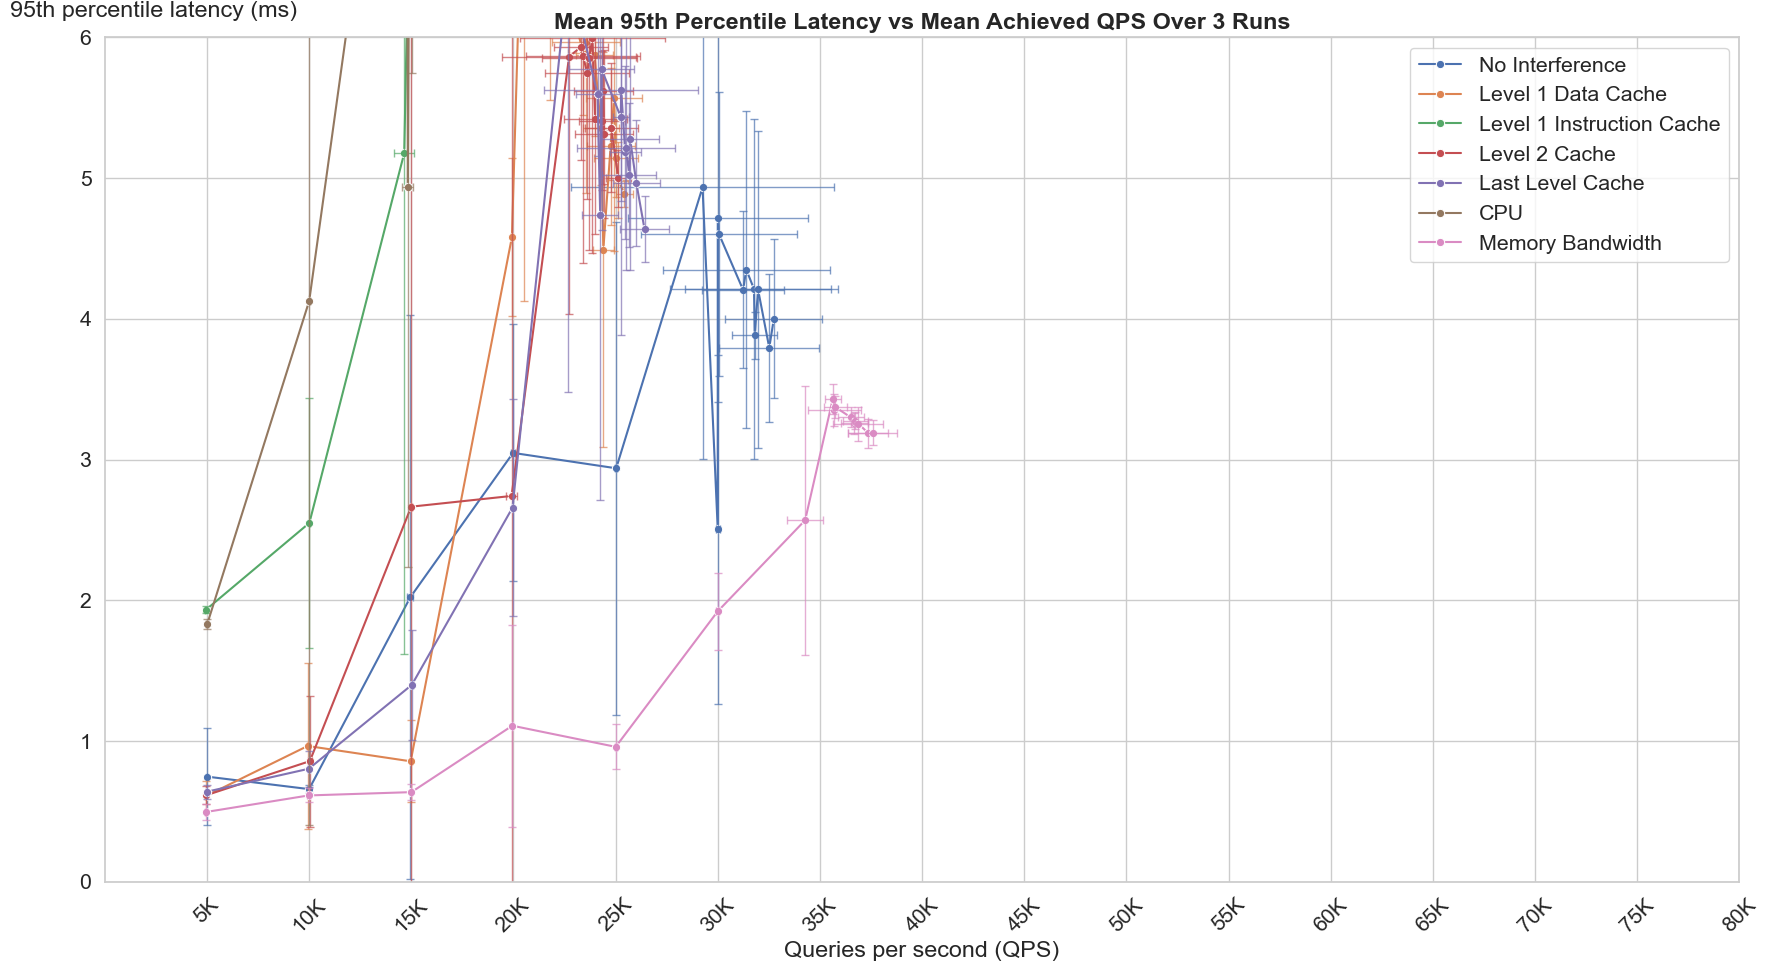

In [8]:
sns.set_theme(style="whitegrid",font_scale=1.4)

fig, ax = plt.subplots(figsize=(18, 10))

plot_with_errorbars(ax, avg_data_no_interference, "No Interference")

plot_with_errorbars(ax, avg_data_l1d, "Level 1 Data Cache")

plot_with_errorbars(ax, avg_data_l1i, "Level 1 Instruction Cache")

plot_with_errorbars(ax, avg_data_l2, "Level 2 Cache")

plot_with_errorbars(ax, avg_data_llc, "Last Level Cache")

plot_with_errorbars(ax, avg_data_cpu, "CPU")

plot_with_errorbars(ax, avg_data_membw, "Memory Bandwidth")

# Logarithmic x-axis
# ax.set_xscale("log")

# Custom ticks every 5000
ticks = np.arange(5000, 80001, 5000)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(t/1000)}K" for t in ticks], rotation=45)

# Limits
ax.set_xlim(0, 80000)
ax.set_ylim(0, 6)

# Labels and title
ax.set_xlabel("Queries per second (QPS)")
ax.set_ylabel(
    "95th percentile latency (ms)",
    rotation=0,
    ha="left",
    va="bottom",
    labelpad=50,
    y=1.02
)
ax.set_title("Mean 95th Percentile Latency vs Mean Achieved QPS Over 3 Runs", fontweight="bold")

# Grid
ax.grid(True, which="major", axis="both")

# Legend
ax.legend()

plt.tight_layout()
plt.show()

/var/folders/b8/_jp9nwg53n54v9nv8qmdfmw00000gn/T/ipykernel_46383/2841137124.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 80000)


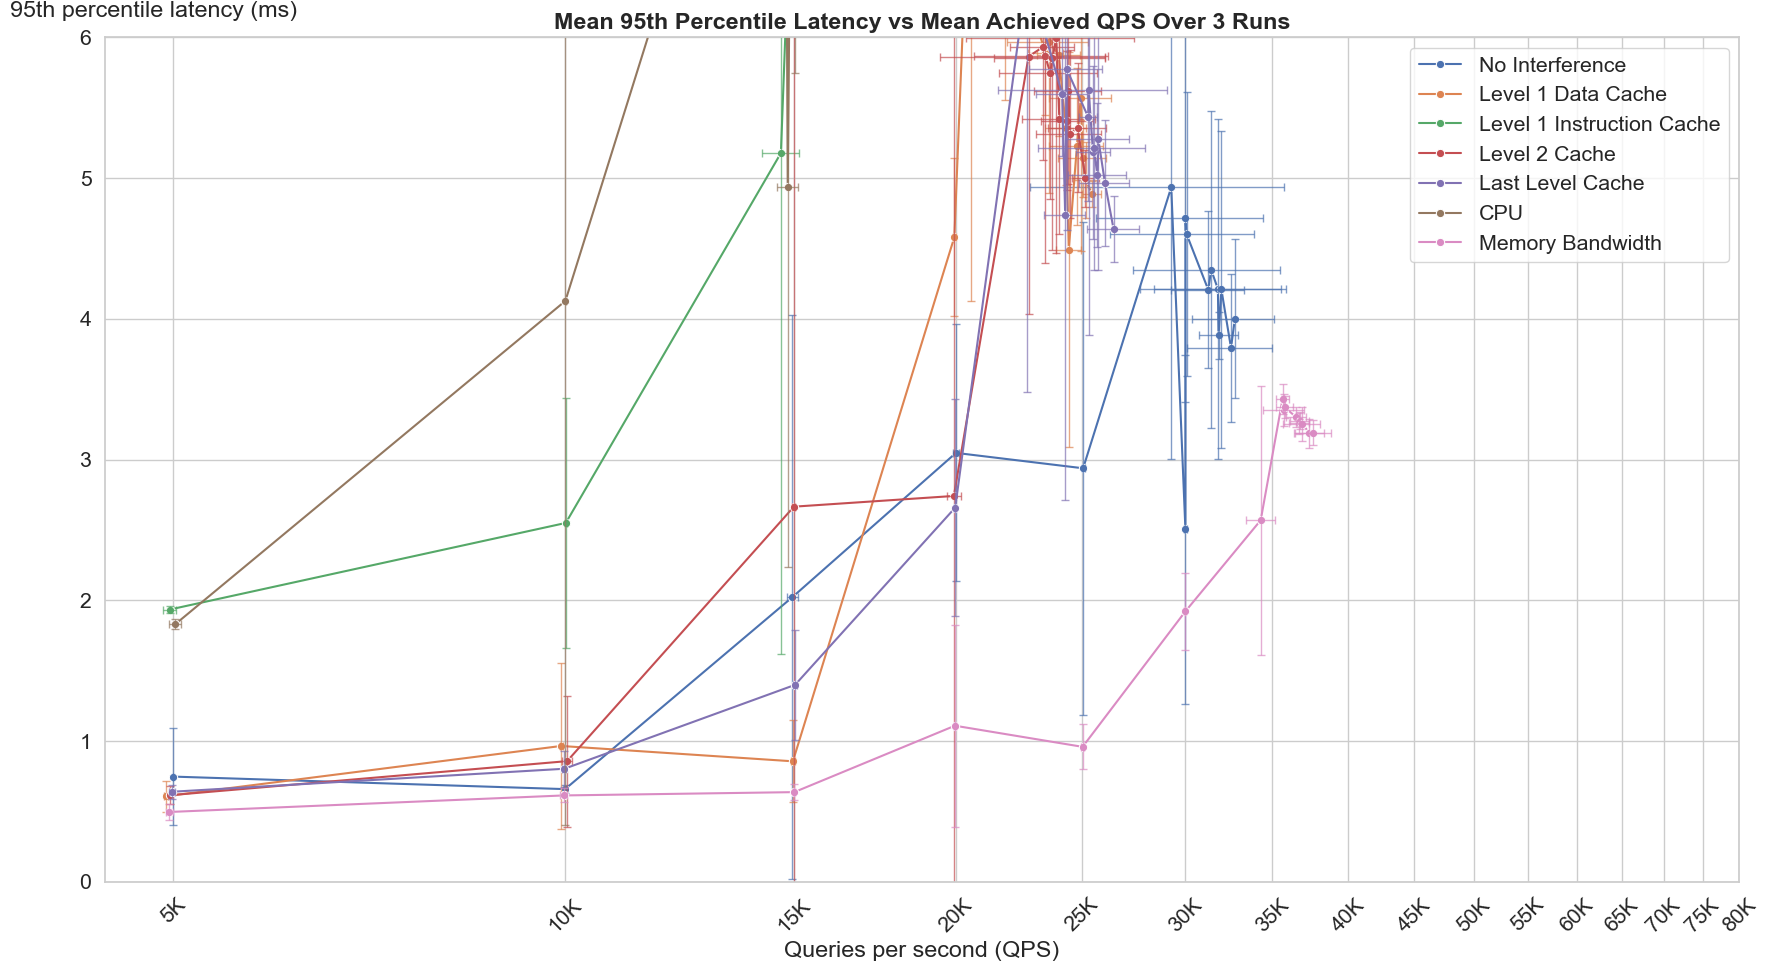

In [9]:
sns.set_theme(style="whitegrid",font_scale=1.4)

fig, ax = plt.subplots(figsize=(18, 10))

plot_with_errorbars(ax, avg_data_no_interference, "No Interference")

plot_with_errorbars(ax, avg_data_l1d, "Level 1 Data Cache")

plot_with_errorbars(ax, avg_data_l1i, "Level 1 Instruction Cache")

plot_with_errorbars(ax, avg_data_l2, "Level 2 Cache")

plot_with_errorbars(ax, avg_data_llc, "Last Level Cache")

plot_with_errorbars(ax, avg_data_cpu, "CPU")

plot_with_errorbars(ax, avg_data_membw, "Memory Bandwidth")

# Logarithmic x-axis
ax.set_xscale("log")

# Custom ticks every 5000
ticks = np.arange(5000, 80001, 5000)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(t/1000)}K" for t in ticks], rotation=45)

# Limits
ax.set_xlim(0, 80000)
ax.set_ylim(0, 6)

# Labels and title
ax.set_xlabel("Queries per second (QPS)")
ax.set_ylabel(
    "95th percentile latency (ms)",
    rotation=0,
    ha="left",
    va="bottom",
    labelpad=50,
    y=1.02
)
ax.set_title("Mean 95th Percentile Latency vs Mean Achieved QPS Over 3 Runs", fontweight="bold")

# Grid
ax.grid(True, which="major", axis="both")

# Legend
ax.legend()

plt.tight_layout()
plt.show()

# Plot that makes more sense to me

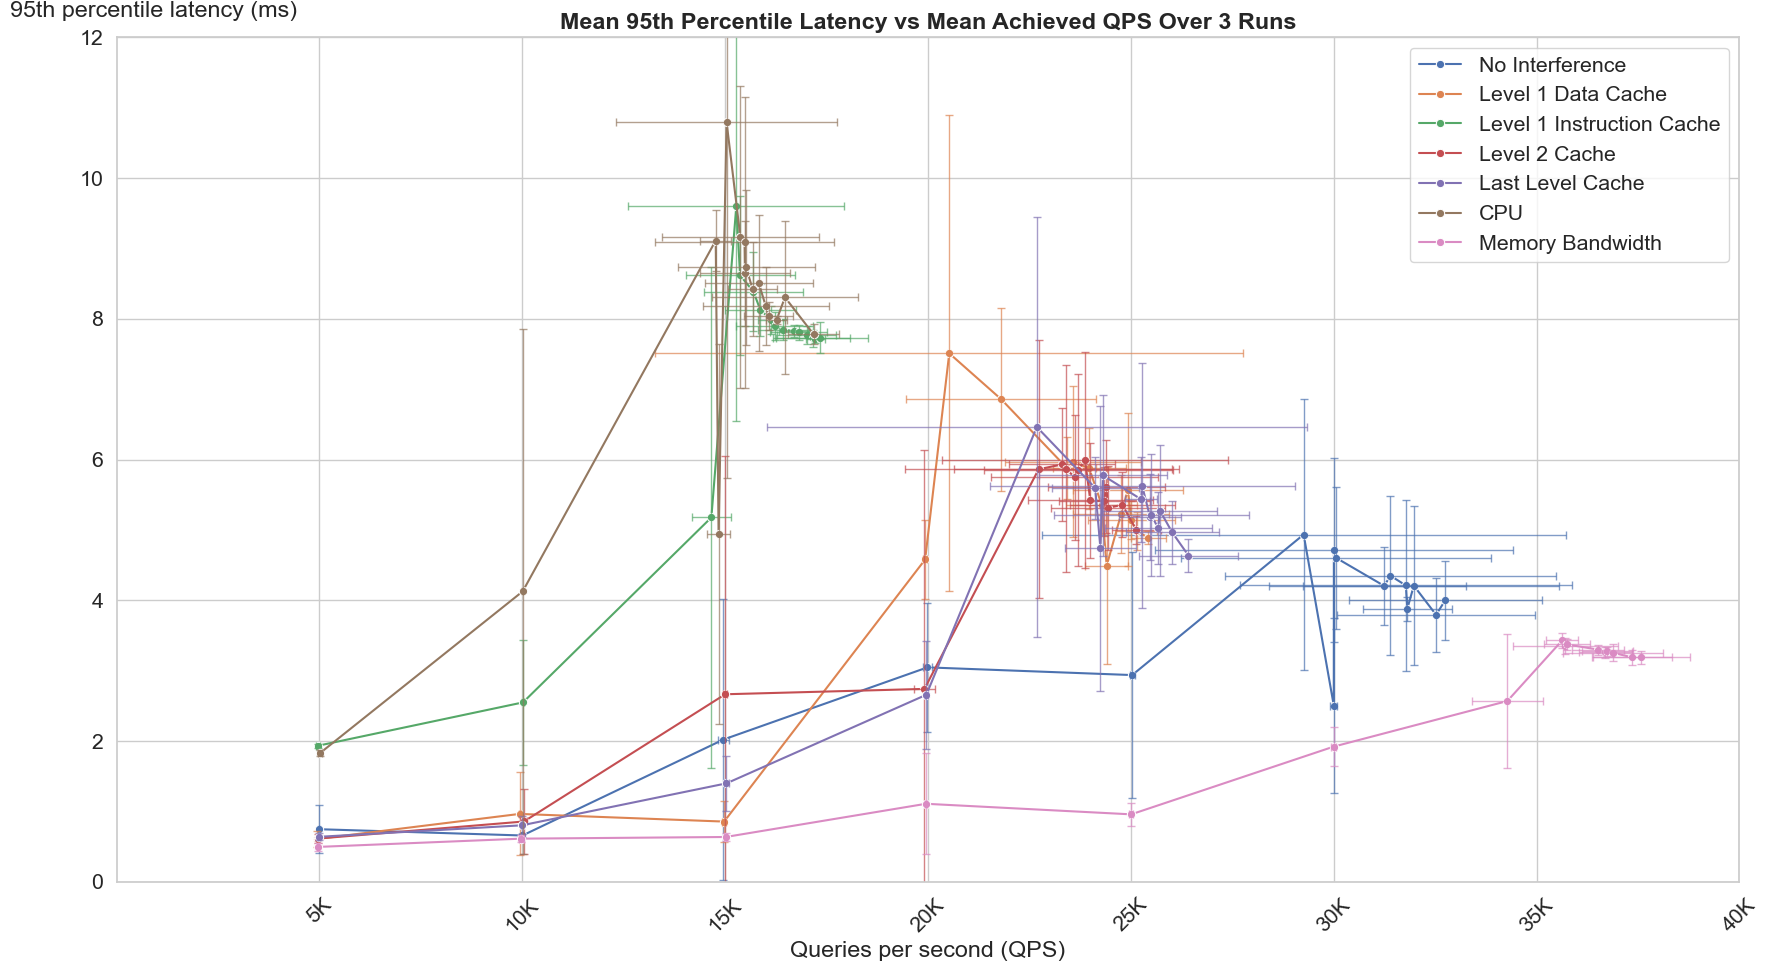

In [11]:
sns.set_theme(style="whitegrid",font_scale=1.4)

fig, ax = plt.subplots(figsize=(18, 10))

plot_with_errorbars(ax, avg_data_no_interference, "No Interference")

plot_with_errorbars(ax, avg_data_l1d, "Level 1 Data Cache")

plot_with_errorbars(ax, avg_data_l1i, "Level 1 Instruction Cache")

plot_with_errorbars(ax, avg_data_l2, "Level 2 Cache")

plot_with_errorbars(ax, avg_data_llc, "Last Level Cache")

plot_with_errorbars(ax, avg_data_cpu, "CPU")

plot_with_errorbars(ax, avg_data_membw, "Memory Bandwidth")

# Logarithmic x-axis
# ax.set_xscale("log")

# Custom ticks every 5000
ticks = np.arange(5000, 40001, 5000)
ax.set_xticks(ticks)
ax.set_xticklabels([f"{int(t/1000)}K" for t in ticks], rotation=45)
ax.xaxis.set_minor_locator(ticker.NullLocator())

# Limits
ax.set_xlim(0, 40000)
ax.set_ylim(0, 12)

# Labels and title
ax.set_xlabel("Queries per second (QPS)")
ax.set_ylabel(
    "95th percentile latency (ms)",
    rotation=0,
    ha="left",
    va="bottom",
    labelpad=50,
    y=1.02
)
ax.set_title("Mean 95th Percentile Latency vs Mean Achieved QPS Over 3 Runs", fontweight="bold")

# Grid
ax.grid(True, which="major", axis="both")

# Legend
ax.legend()

plt.tight_layout()
plt.show()